# 🧩 Chunking Strategy Tester

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/chunk-optimizer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/chunk-optimizer/demo.ipynb)

**Bad chunks = bad answers.** In a RAG system, the retriever can only surface a chunk that *actually contains* the answer. Chunk too big and you dilute the signal (and waste context tokens); chunk too small and the answer gets split across chunk boundaries so no single chunk is retrievable.

This notebook splits a small corpus with several chunking strategies, retrieves over the chunks with a dependency-free lexical scorer, and scores each strategy on a **gold eval set** - so you pick a chunking config on *evidence* instead of vibes.

**What we cover**
1. The sample corpus + gold eval set
2. Chunking strategies (whole-doc, fixed-word, sentence-based, sliding overlap)
3. A tiny offline TF-IDF retriever
4. Scoring each strategy: hit rate @ k and MRR
5. 📊 Visualization of the retrieval-quality-vs-chunk-size tradeoff
6. Try your own corpus

Fully offline - no API keys, no embeddings service.

## Step 1 - The corpus and the gold eval set

We use four short policy documents. The **eval set** pins each question to the document and the exact answer span a good chunk must contain. This is our ground truth.

In [1]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Tuple
import math, re

SAMPLE_DOCS: Dict[str, str] = {
    "refund_policy": (
        "Customers may request a refund within 30 days of purchase. "
        "Refunds are issued to the original payment method within 5 to 7 "
        "business days. Digital goods are non-refundable once downloaded. "
        "To start a refund, email support with your order number. "
        "Shipping fees are not refundable except when the item arrived damaged."
    ),
    "security": (
        "All customer data is encrypted at rest using AES-256. "
        "Data in transit is protected with TLS 1.3. "
        "We run a quarterly third-party penetration test. "
        "Access to production databases requires multi-factor authentication. "
        "Secrets are stored in a managed vault and rotated every 90 days."
    ),
    "onboarding": (
        "New hires complete IT setup on day one and receive a laptop. "
        "The buddy program pairs each new hire with a mentor for 30 days. "
        "Benefits enrollment must be completed within the first two weeks. "
        "The first performance check-in happens at the 90-day mark. "
        "All employees finish security awareness training before week three."
    ),
    "sla": (
        "Priority 1 incidents receive a response within 15 minutes. "
        "Priority 2 incidents receive a response within 2 hours. "
        "Our uptime commitment is 99.9 percent measured monthly. "
        "Scheduled maintenance windows are announced 72 hours in advance. "
        "Service credits apply when monthly uptime falls below the commitment."
    ),
}

@dataclass
class EvalCase:
    qid: str
    question: str
    doc_id: str
    answer_span: str

SAMPLE_CASES: List[EvalCase] = [
    EvalCase("q1", "How long do I have to ask for a refund?", "refund_policy", "within 30 days"),
    EvalCase("q2", "How are refunds paid back?", "refund_policy", "original payment method within 5 to 7"),
    EvalCase("q3", "How is data encrypted when stored?", "security", "AES-256"),
    EvalCase("q4", "How often are secrets rotated?", "security", "rotated every 90 days"),
    EvalCase("q5", "When does a new hire get a mentor?", "onboarding", "buddy program pairs each new hire with a mentor for 30 days"),
    EvalCase("q6", "When is the first performance review?", "onboarding", "90-day mark"),
    EvalCase("q7", "What is the response time for a P1 incident?", "sla", "within 15 minutes"),
    EvalCase("q8", "What is the monthly uptime commitment?", "sla", "99.9 percent"),
]

print(f"{len(SAMPLE_DOCS)} documents, {len(SAMPLE_CASES)} gold questions")
for c in SAMPLE_CASES[:3]:
    print(f"  [{c.qid}] {c.question}  ->  {c.doc_id}: \"{c.answer_span}\"")

4 documents, 8 gold questions
  [q1] How long do I have to ask for a refund?  ->  refund_policy: "within 30 days"
  [q2] How are refunds paid back?  ->  refund_policy: "original payment method within 5 to 7"
  [q3] How is data encrypted when stored?  ->  security: "AES-256"


## Step 2 - Chunking strategies

A strategy turns each document into a list of `Chunk`s. We compare six:

| Strategy | Idea |
|---|---|
| `whole_doc` | no splitting - one chunk per doc (baseline) |
| `words_8` | fixed 8-word windows (very small) |
| `words_15` | fixed 15-word windows |
| `words_20_overlap_5` | 20-word windows with 5-word overlap |
| `sentence_1` | one sentence per chunk |
| `sentence_2` | two sentences per chunk |

Overlap matters: it stops an answer from falling *between* two chunks.

In [2]:
@dataclass
class Chunk:
    chunk_id: str
    doc_id: str
    text: str

_WORD_RE = re.compile(r"\S+")
_SENT_RE = re.compile(r"(?<=[.!?])\s+")

def _words(text: str) -> List[str]:
    return _WORD_RE.findall(text)

def chunk_fixed_words(doc_id, text, size, overlap=0):
    if overlap < 0 or overlap >= size:
        overlap = max(0, min(overlap, size - 1))
    words = _words(text)
    chunks, step, i, idx = [], size - overlap, 0, 0
    while i < len(words):
        chunks.append(Chunk(f"{doc_id}#w{idx}", doc_id, " ".join(words[i:i+size])))
        idx += 1; i += step
    return chunks

def chunk_by_sentence(doc_id, text, per_chunk=1):
    sents = [s.strip() for s in _SENT_RE.split(text.strip()) if s.strip()]
    chunks = []
    for idx, i in enumerate(range(0, len(sents), per_chunk)):
        chunks.append(Chunk(f"{doc_id}#s{idx}", doc_id, " ".join(sents[i:i+per_chunk])))
    return chunks

def chunk_whole_doc(doc_id, text):
    return [Chunk(f"{doc_id}#full", doc_id, text)]

def build_strategies():
    def _apply(fn):
        def run(docs):
            out = []
            for doc_id, text in docs.items():
                out.extend(fn(doc_id, text))
            return out
        return run
    return {
        "whole_doc": _apply(chunk_whole_doc),
        "words_8": _apply(lambda d, t: chunk_fixed_words(d, t, 8, 0)),
        "words_15": _apply(lambda d, t: chunk_fixed_words(d, t, 15, 0)),
        "words_20_overlap_5": _apply(lambda d, t: chunk_fixed_words(d, t, 20, 5)),
        "sentence_1": _apply(lambda d, t: chunk_by_sentence(d, t, 1)),
        "sentence_2": _apply(lambda d, t: chunk_by_sentence(d, t, 2)),
    }

demo = build_strategies()["sentence_1"](SAMPLE_DOCS)
print(f"sentence_1 produced {len(demo)} chunks. First three:")
for c in demo[:3]:
    print(f"  {c.chunk_id}: {c.text}")

sentence_1 produced 20 chunks. First three:
  refund_policy#s0: Customers may request a refund within 30 days of purchase.
  refund_policy#s1: Refunds are issued to the original payment method within 5 to 7 business days.
  refund_policy#s2: Digital goods are non-refundable once downloaded.


## Step 3 - A dependency-free lexical retriever

No embeddings service, no API. Just TF-IDF cosine similarity between the query and each chunk. Good enough to expose the *chunking* effect, which is what we are isolating here.

In [3]:
_TOKEN_RE = re.compile(r"[a-z0-9]+")

def _tokenize(text):
    return _TOKEN_RE.findall(text.lower())

class LexicalRetriever:
    def __init__(self, chunks):
        self.chunks = chunks
        self.df, self._tf = {}, []
        for ch in chunks:
            counts = {}
            for tok in _tokenize(ch.text):
                counts[tok] = counts.get(tok, 0) + 1
            self._tf.append(counts)
            for tok in counts:
                self.df[tok] = self.df.get(tok, 0) + 1
        self.n = max(1, len(chunks))
        self._vecs = [self._to_vec(tf) for tf in self._tf]
    def _idf(self, tok):
        return math.log((1 + self.n) / (1 + self.df.get(tok, 0))) + 1.0
    def _to_vec(self, tf):
        return {tok: c * self._idf(tok) for tok, c in tf.items()}
    @staticmethod
    def _cosine(a, b):
        if not a or not b: return 0.0
        common = set(a) & set(b)
        dot = sum(a[t] * b[t] for t in common)
        na = math.sqrt(sum(v*v for v in a.values()))
        nb = math.sqrt(sum(v*v for v in b.values()))
        return dot / (na * nb) if na and nb else 0.0
    def query(self, text, k=3):
        q = {}
        for tok in _tokenize(text):
            q[tok] = q.get(tok, 0) + 1
        q_vec = self._to_vec(q)
        scored = [(self.chunks[i], self._cosine(q_vec, self._vecs[i])) for i in range(len(self.chunks))]
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:k]

r = LexicalRetriever(demo)
print("Query: 'How often are secrets rotated?'  ->  top-3 chunks (sentence_1):")
for ch, sc in r.query("How often are secrets rotated?", k=3):
    print(f"  {sc:.3f}  {ch.chunk_id}: {ch.text}")

Query: 'How often are secrets rotated?'  ->  top-3 chunks (sentence_1):
  0.346  security#s4: Secrets are stored in a managed vault and rotated every 90 days.
  0.078  refund_policy#s2: Digital goods are non-refundable once downloaded.
  0.070  sla#s3: Scheduled maintenance windows are announced 72 hours in advance.


## Step 4 - Score each strategy

A chunk **wins** a query only if it comes from the right document *and* contains the exact answer span. Two metrics:

- **hit rate @ k** - fraction of questions whose answer-bearing chunk lands in the top-k.
- **MRR** - mean reciprocal rank of the first winning chunk (rewards ranking it #1, not just somewhere in top-k).

In [4]:
@dataclass
class StrategyResult:
    name: str
    n_chunks: int
    avg_chunk_words: float
    hit_rate_at_k: float
    mrr: float
    per_query: List[dict] = field(default_factory=list)

def _chunk_has_answer(chunk, case):
    return chunk.doc_id == case.doc_id and case.answer_span.lower() in chunk.text.lower()

def evaluate_strategy(name, strategy, docs, cases, k=3):
    chunks = strategy(docs)
    retriever = LexicalRetriever(chunks)
    avg_words = sum(len(_words(c.text)) for c in chunks) / len(chunks) if chunks else 0.0
    hits, rr_sum, per_query = 0, 0.0, []
    for case in cases:
        ranked = retriever.query(case.question, k=k)
        rank = None
        for pos, (chunk, _s) in enumerate(ranked, start=1):
            if _chunk_has_answer(chunk, case):
                rank = pos; break
        hits += int(rank is not None)
        rr_sum += (1.0 / rank) if rank else 0.0
        per_query.append({"qid": case.qid, "hit": rank is not None, "rank": rank})
    n = max(1, len(cases))
    return StrategyResult(name, len(chunks), round(avg_words, 1),
                          round(hits/n, 3), round(rr_sum/n, 3), per_query)

def compare_strategies(docs=None, cases=None, k=3):
    docs = docs or dict(SAMPLE_DOCS)
    cases = cases or list(SAMPLE_CASES)
    results = [evaluate_strategy(n, s, docs, cases, k=k) for n, s in build_strategies().items()]
    results.sort(key=lambda r: (r.hit_rate_at_k, r.mrr), reverse=True)
    return results

results = compare_strategies(k=3)
print(f"{'strategy':22} {'chunks':>6} {'avg_w':>6} {'hit@3':>6} {'mrr':>6}")
print("-" * 52)
for r in results:
    print(f"{r.name:22} {r.n_chunks:>6} {r.avg_chunk_words:>6} {r.hit_rate_at_k:>6} {r.mrr:>6}")

strategy               chunks  avg_w  hit@3    mrr
----------------------------------------------------
whole_doc                   4   48.0    1.0    1.0
sentence_2                 12   16.0    1.0  0.938
sentence_1                 20    9.6    1.0  0.854
words_15                   14   13.7   0.75   0.75
words_20_overlap_5         14   17.3   0.75  0.604
words_8                    26    7.4  0.375  0.188


## Step 5 - 📊 The tradeoff, visualized

The chart tells the whole story: retrieval quality vs. average chunk size. Tiny chunks split answers (quality falls); the whole-document baseline scores well but at maximum token cost per retrieved chunk. The useful middle is sentence/paragraph-aware chunking.

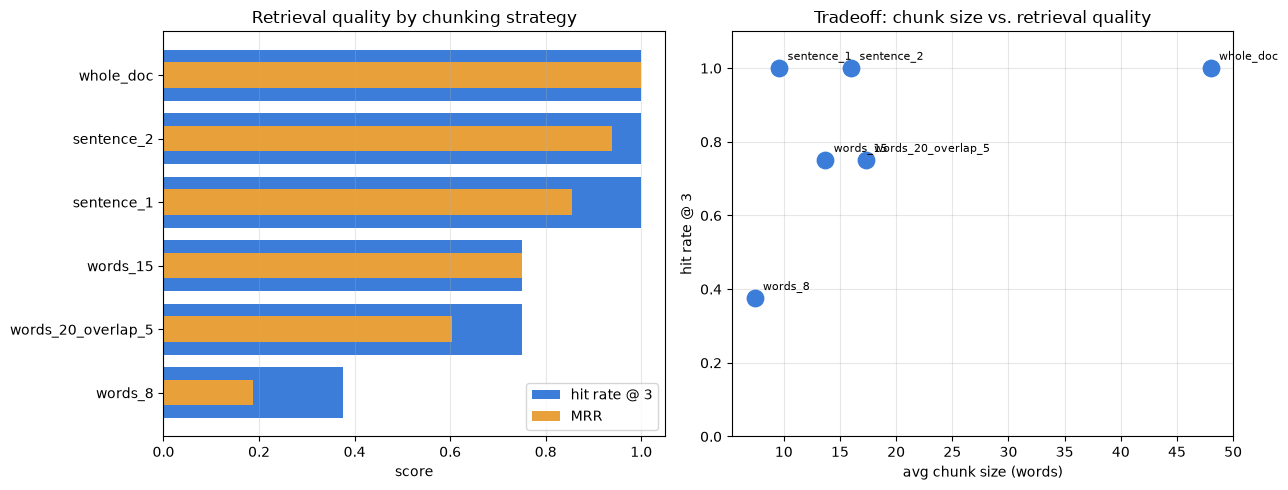

Saved strategy_comparison.png


In [5]:
import matplotlib.pyplot as plt

names = [r.name for r in results]
hit = [r.hit_rate_at_k for r in results]
mrr = [r.mrr for r in results]
sizes = [r.avg_chunk_words for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

y = range(len(names))
ax1.barh(y, hit, color="#3b7dd8", label="hit rate @ 3")
ax1.barh([i + 0.0 for i in y], mrr, color="#e8a13a", height=0.4, label="MRR")
ax1.set_yticks(list(y)); ax1.set_yticklabels(names)
ax1.invert_yaxis(); ax1.set_xlim(0, 1.05)
ax1.set_xlabel("score"); ax1.set_title("Retrieval quality by chunking strategy")
ax1.legend(loc="lower right"); ax1.grid(axis="x", alpha=0.3)

ax2.scatter(sizes, hit, s=140, color="#3b7dd8", zorder=3)
for n, x, yv in zip(names, sizes, hit):
    ax2.annotate(n, (x, yv), textcoords="offset points", xytext=(6, 6), fontsize=8)
ax2.set_xlabel("avg chunk size (words)"); ax2.set_ylabel("hit rate @ 3")
ax2.set_title("Tradeoff: chunk size vs. retrieval quality")
ax2.set_ylim(0, 1.1); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("strategy_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved strategy_comparison.png")

## Summary

- The retriever can only answer from a chunk that **contains** the answer - so chunking sets the ceiling on RAG quality, before the LLM ever runs.
- **Too small** (`words_8`): answer spans get split across boundaries -> hit rate collapses.
- **Whole document**: high hit rate, but every retrieval dumps the full doc into the prompt (token cost + signal dilution at scale).
- **Sentence/paragraph-aware** chunking is the reliable middle ground; overlap rescues answers that straddle a boundary.
- Best move: keep a small gold eval set and **re-run this test whenever you change chunking** - the same discipline as `rag-eval` (Day 82), one layer earlier in the pipeline.

In [6]:
# --- Try your own corpus --------------------------------------------------
# Drop in your documents and questions, then re-run. Everything above is
# self-contained, so this cell alone reproduces the full leaderboard.
#
# my_docs = {
#     "faq_billing": "Invoices are sent on the first of each month. "
#                    "Late payments incur a 2 percent fee after 15 days.",
#     "faq_access":  "Admins can invite users from the Settings page. "
#                    "Seats are billed per active user each month.",
# }
# my_cases = [
#     EvalCase("m1", "When are invoices sent?", "faq_billing", "first of each month"),
#     EvalCase("m2", "Who can invite users?", "faq_access", "Admins can invite users"),
# ]
# for r in compare_strategies(my_docs, my_cases, k=3):
#     print(f"{r.name:22} hit@3={r.hit_rate_at_k}  mrr={r.mrr}  chunks={r.n_chunks}")
print("Uncomment the block above to test your own corpus.")

Uncomment the block above to test your own corpus.


---
**Day 83 of Phoebe's FDE portfolio** · LLMOps & GenAI Platform

- 📦 Repo: [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)
- 🖥️ Streamlit version: `pip install -r requirements.txt && streamlit run app.py` (interactive leaderboard + per-query inspector)
- 🔗 Pairs with **Day 82 - RAG Evaluation Harness**: chunk here, then score retrieval there.